# Task 01: Data Visualization
Create a bar chart or histogram to visualize the distribution of a categorical or continuous variable.

### 1. Load and Clean Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# Load population and metadata
pop_df = pd.read_csv('API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv', skiprows=4)
meta_df = pd.read_csv('Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv')

# Merge metadata into population dataframe
df = pd.merge(pop_df, meta_df[['Country Code', 'Region', 'IncomeGroup']], on='Country Code', how='left')

# Filter out regional aggregates (keep individual countries)
df = df[df['Region'].notna()].dropna(subset=['2024'])
df[['Country Name', 'Region', 'IncomeGroup', '2024']].head()

,Country Name,Region,IncomeGroup,2024
0,Aruba,Latin America & Caribbean,High income,107624.0
2,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,42647492.0
4,Angola,Sub-Saharan Africa,Lower middle income,37885849.0
5,Albania,Europe & Central Asia,Upper middle income,2714617.0
6,Andorra,Europe & Central Asia,High income,81938.0


### 2. Continuous Variable: Population Distribution (Histogram)

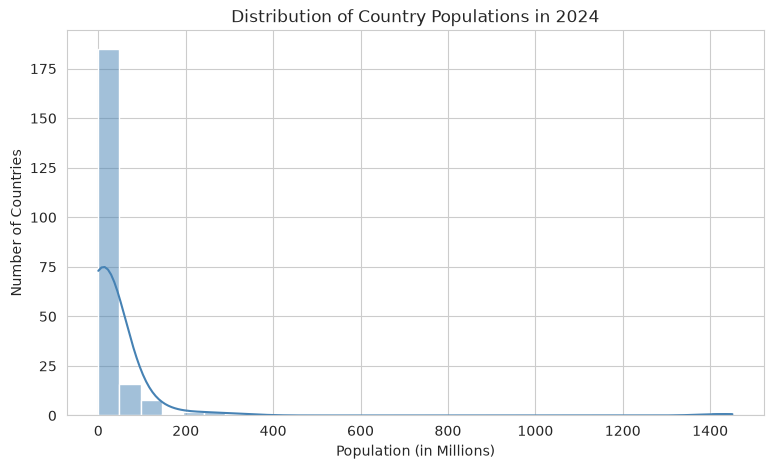

In [2]:
plt.figure(figsize=(9, 5))
sns.histplot(df['2024'] / 1e6, kde=True, bins=30, color='steelblue')
plt.title('Distribution of Country Populations in 2024')
plt.xlabel('Population (in Millions)')
plt.ylabel('Number of Countries')
plt.show()

### 3. Categorical Variable: Distribution by Region (Bar Chart)

/tmp/ipykernel_24858/2231437195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


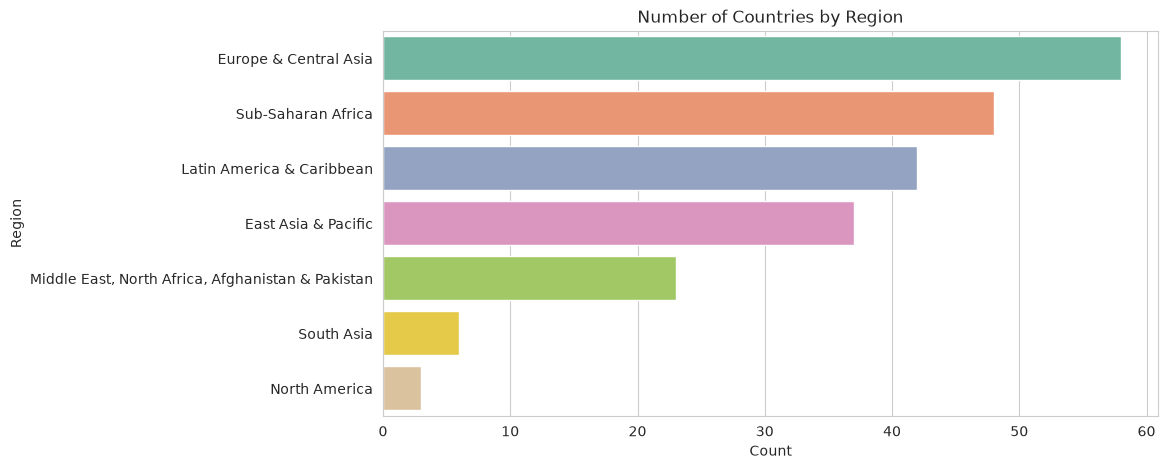

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y='Region',
    order=df['Region'].value_counts().index,
    palette='Set2'
)
plt.title('Number of Countries by Region')
plt.xlabel('Count')
plt.ylabel('Region')
plt.show()

### 4. Categorical Variable: Distribution by Income Group (Bar Chart)

/tmp/ipykernel_24858/1780591031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


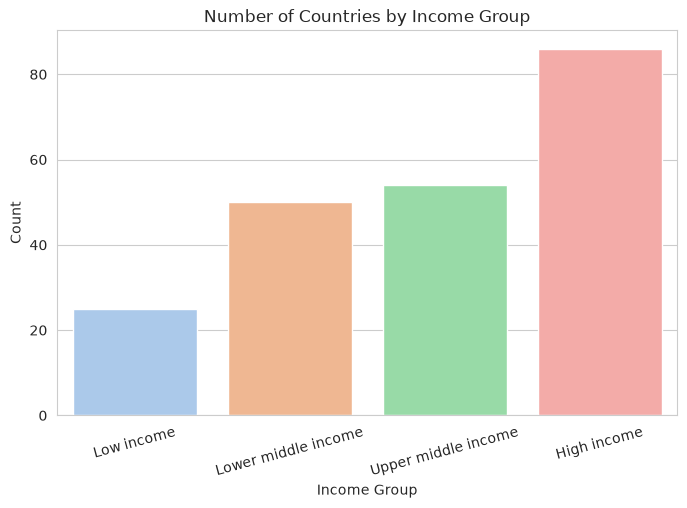

In [4]:
plt.figure(figsize=(8, 5))
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
sns.countplot(
    data=df,
    x='IncomeGroup',
    order=income_order,
    palette='pastel'
)
plt.title('Number of Countries by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

### 5. Top 10 Most Populated Countries (2024)

/tmp/ipykernel_24858/1792776131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


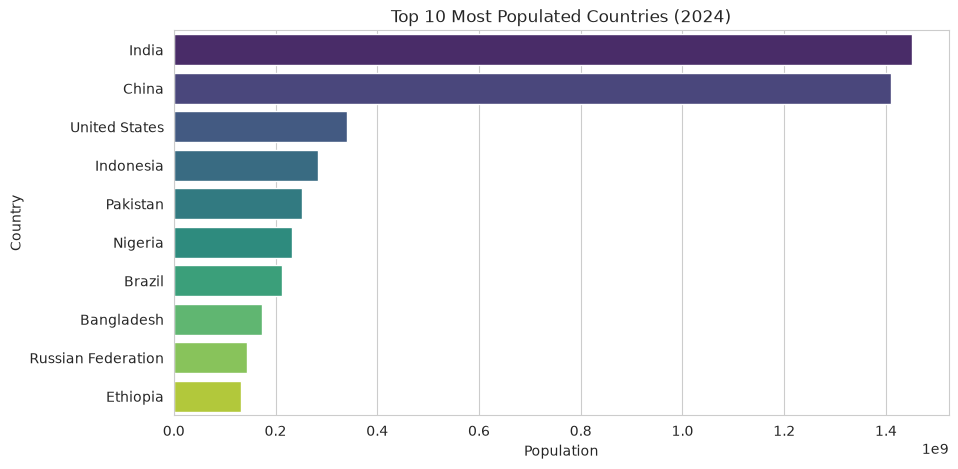

In [5]:
top10 = df.nlargest(10, '2024')

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top10,
    x='2024',
    y='Country Name',
    palette='viridis'
)
plt.title('Top 10 Most Populated Countries (2024)')
plt.xlabel('Population')
plt.ylabel('Country')
plt.show()